# Colop: Parse

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
src_id = 'colop'
n_chunks = 60

# Source file to parts and new_lines 

In [3]:
raw_lines = open("../../textos/colop-pk.txt", "r").readlines()

In [4]:
part_num = 0
chap_num = 0
line_num = 0
new_lines = []
part_name = ''
parts = []
for line in raw_lines:
    if "<PARTE>" in line:
        part_num += 1
        part_name = line.strip().replace("<PARTE>", "")
        chap_num = 0
    if "<CAPITULO>" in line:
        chap_num += 1
        line_num = 0
        parts.append((part_num, part_name, chap_num, line.strip().replace("<CAPITULO>","")))
    line_num += 1
    new_lines.append((part_num, chap_num, line_num, line))

# parts to DIV

In [5]:
DIV = pd.DataFrame(parts)
DIV.columns = ['parte', 'parte_nombre', 'capit', 'capit_nombre']
DIV.head()

,parte,parte_nombre,capit,capit_nombre
0,1,NAB'E,1,ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I'
1,1,NAB'E,2,ARE UTZIJOXIK WA'E
2,1,NAB'E,3,TA XWINAQIR K'U RI ULEW KUMAL
3,1,NAB'E,4,"K'EJE K'UT UTIJTOB'EXIK CHIK WINAQ TZ'AQ,"
4,1,NAB'E,5,K'ATE K'UT UB'IXIK RI' CHI KECH RI E NIK'WACHI...


In [6]:
# PARTE = DIV.value_counts(['parte','parte_nombre']).to_frame('n').reset_index().set_index('parte').sort_index()
# PARTE

# DIV to DOC

In [7]:
DOC = DIV.set_index(['parte','capit'])
DOC

parte_nombre                                       capit_nombre
parte capit                                                                
1     1            NAB'E            ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I'
      2            NAB'E                                 ARE UTZIJOXIK WA'E
      3            NAB'E                      TA XWINAQIR K'U RI ULEW KUMAL
      4            NAB'E          K'EJE K'UT UTIJTOB'EXIK CHIK WINAQ TZ'AQ,
      5            NAB'E  K'ATE K'UT UB'IXIK RI' CHI KECH RI E NIK'WACHI...
      6            NAB'E                          K'ATE K'UT KIK'ISIK CHIK,
2     1            UKAB'         ARE K'UT XA JUB'IQ' SAQNATANOJ UWACH ULEW,
      2            UKAB'  K'EJE K'UT XCHIQAB'IJ CHIK TA XKAMIK WUQUB' KA...
      3            UKAB'               WA'E CHI K'UTE UB'ANOJ CHIK SIPAKNA,
      4            UKAB'                             ARE CHIK UCH'AKATAJIK,
      5            UKAB'                    JUN CHI K'UT XCHIQAB'IJ UB'IXIK
3     1              ROX  ARE CHI K'UT XCHIQAB'IJ CHIK UB'I' KIQAJAW RI ...
      2              ROX  ARE CHI K'UT XCHIQAB'IJ CHIK KIB'E'IK CHI XIB'...
      3              ROX  K'ATE PUCH TA XEB'EK JUN JUNAJPU, WUQUB' JUNAJPU.
      4              ROX                K'ATE K'UT XE'OPONIK PA Q'EQUMA JA,
      5              ROX                 WA CHI K'UTE UTZIJOXIK JUN Q'APOJ,
      6              ROX    ARE K'UTE K'O RI UCHUCH JUN B'ATZ', JUN CHOWEN,
      7              ROX  ARE CHIK XCHIQATZIJOJ KALAXIK JUNAJPU, SXB'ALA...
      8              ROX   TA XEB'E K'UT CHILA' CHUXE' CHE', Q'ANTE' UB'I';
      9              ROX               K'ATE K'UT XUKAQ'AT ULA CH'O RI KIK'
      10             ROX  TA XEPE K'UT NIMA JOK K'U KIB'E RI K'AJOLAB' C...
      11             ROX                                     TA XEB'E K'UT,
      12             ROX                 K'ATE K'UT TA XE'OK PA Q'EQUMA JA,
      13             ROX  ARE K'UT WA'E KINAB'AL, KIKAMIK JUNAJPU, XB'AL...
      14             ROX  K'ATE PUCH URAYINIK, UMALINIK PU KIK'UX AJAWAB...
4     1             UKAJ  WA'E K'UT UTIKERIK TA XNA'OJIX WINAQ, TA XTZUK...
      2             UKAJ        WA'E KIB'I NAB'E WINAQ XETZ'AQIK, XEB'ITIK:
      3             UKAJ            ARE K'UT UXE' QECH, RI OJ K'ECHE' WINAQ
      4             UKAJ                         ARE K'UT UB'I' JUYUB' WA',
      5             UKAJ    WA'E K'UTE' USAQIRIK, UWACHINIK PUCH Q'IJ, IK',
      6             UKAJ                              WA K'UTE' KIK'ATONIK,
      7             UKAJ  WA'E UTIKARIK CHIK RELEQ'AXIK WINAQ, AMAQ' kum...
      8             UKAJ                   ARE K'U WA' UK'AMIK UNA'OJ AMAQ'
      9             UKAJ                                 K'ATE PUCH XEB'EK,
      10            UKAJ           WA'E K'UTE KIMOLOWIK KIB' KONOJEL AMAQ',
      11            UKAJ  ARE CHIK WI XCHIQAB'IJ CHIK KIKAMIK B'alam Kit...
5     1              RO'                    K'ATE PUCH TA XKIK'UXLAJ KIB'IK
      2              RO'                            TA XE'UL CHI K'U CHIRI'
      3              RO'        WA'E K'UTE KIB'I' AJAWAB' CHUWACH KAWIQIB'.
      4              RO'       ARE CHI K'U AJAWAB' WA' CHUWACH NIJA'IB'AB':
      5              RO'                     ARE CHI K'UT AJAW K'ICHE' WA'.
      6              RO'     KA'IB' CHINAMIT CHI NAY PUCH SAQIKIB' AJAWAB':
      7              RO'           WA' CHI K'UTE KIB'I' CHIK UWAQ LE' AJAW,
      8              RO'    ARE K'UT XCHIQAB'IJ CHIK UB'I' ROCHOCH KAB'AWIL
      9              RO'  ARE CHI K'UT XCHIQACHOLO ULE'EL AJAWAB' RUK' K...
      10             RO'               ARE CHI XCHIQAB'IJ CHIK RE CHINAMIT,
      11             RO'   ARE UB'INA'M WI B'ELEJEB' CHINAMIT CHI KAWIQIB',
      12             RO'                          WA K'UTE RECH NIJA'IB'AB'
      13             RO'      ARE CHIK XCHIQAB'IJ RAJAWAL JUJUN CHI NIM JA:
      14             RO'                     ARE CHI K'UT RECH AJAW K'ICHE'
      15             RO'                  ARE K'U RI E OXIB'

# new_lines to lines

In [8]:
lines = pd.DataFrame(new_lines, columns=['parte', 'capit', 'line_num', 'line_str'])\
    .set_index(['parte', 'capit', 'line_num'])
lines.line_str = lines.line_str.str.strip()
lines = lines[~lines.line_str.str.match("<PARTE>")]
lines.line_str = lines.line_str.str.replace("<CAPITULO>", "")
lines

line_str
parte capit line_num                                                  
1     1     1                  ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I'
            2                                 Waral xchiqatz'ib'aj wi,
            3                              xchiqatikib'a' wi ojer tzij
            4                                             utikarib'al,
            5         uxe'nab'al puch ronojel xb'an pa tinamit K'iche'
...                                                                ...
5     15    17                                              K'o nab'e,
            18                                    ojer, kumal ajawab'.
            19                                          Sachinaq chik.
            20             Xere k'u ri mixutzinik chi konojel K'iche',
            21                                       Sta. Cruz, ub'i'.

[6716 rows x 1 columns]

# lines into DOC

In [9]:
DOC['doc_str'] = lines.groupby(['parte','capit']).line_str\
    .apply(lambda x: ' '.join(x)).to_frame('doc_str')
DOC['n_chars'] = DOC.doc_str.str.len()
DOC['p'] = DOC.n_chars / DOC.n_chars.sum().sum()
DOC.head()

parte_nombre                                       capit_nombre  \
parte capit                                                                   
1     1            NAB'E            ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I'   
      2            NAB'E                                 ARE UTZIJOXIK WA'E   
      3            NAB'E                      TA XWINAQIR K'U RI ULEW KUMAL   
      4            NAB'E          K'EJE K'UT UTIJTOB'EXIK CHIK WINAQ TZ'AQ,   
      5            NAB'E  K'ATE K'UT UB'IXIK RI' CHI KECH RI E NIK'WACHI...   

                                                       doc_str  n_chars  \
parte capit                                                               
1     1      ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I' Waral ...     1341   
      2      ARE UTZIJOXIK WA'E k'akatz'ininoq, k'akachamam...     1825   
      3      TA XWINAQIR K'U RI ULEW KUMAL Xa kitzij xk'oje...     3396   
      4      K'EJE K'UT UTIJTOB'EXIK CHIK WINAQ TZ'AQ, WINA...     1219   
      5      K'ATE K'UT UB'IXIK RI' CHI KECH RI E NIK'WACHI...     2436   

                    p  
parte capit            
1     1      0.008013  
      2      0.010906  
      3      0.020293  
      4      0.007284  
      5      0.014557

# DOC to TOKEN

In [10]:
TOKEN = DOC.doc_str.str.split(expand=True).stack().to_frame('token_str')
TOKEN.index.names = list(TOKEN.index.names)[:2] + ['token_num']
TOKEN['term_str'] = TOKEN.token_str.str.replace(r"[!()?,.;:-]+", "", regex=True).str.lower()
TOKEN

token_str term_str
parte capit token_num                   
1     1     0              ARE'     are'
            1              UXE'     uxe'
            2              OJER     ojer
            3              TZIJ     tzij
            4             WARAL    waral
...                         ...      ...
5     15    89          konojel  konojel
            90         K'iche',  k'iche'
            91             Sta.      sta
            92            Cruz,     cruz
            93           ub'i'.    ub'i'

[27092 rows x 2 columns]

# TOKEN to VOCAB 

In [11]:
VOCAB = TOKEN.term_str.value_counts().to_frame('n').sort_index()
VOCAB['p'] = VOCAB.n / VOCAB.n.sum()
VOCAB['i'] = np.log2(1/VOCAB.p)
VOCAB['h'] = VOCAB.p * VOCAB.i
VOCAB

,n,p,i,h
term_str,,,,
,36,0.001329,9.555654,0.012698
',2,0.000074,13.725579,0.001013
'ek,1,0.000037,14.725579,0.000544
'ri,1,0.000037,14.725579,0.000544
'ut,1,0.000037,14.725579,0.000544
...,...,...,...,...
yoq'b'al,1,0.000037,14.725579,0.000544
yoq'otajinaq,1,0.000037,14.725579,0.000544
yujuj,1,0.000037,14.725579,0.000544


# TOKEN to CHUNK

In [12]:
TOKEN['chunk_num'] = pd.cut(TOKEN.reset_index().index, n_chunks, labels=[x for x in range(n_chunks)])
TOKEN

token_str term_str chunk_num
parte capit token_num                             
1     1     0              ARE'     are'         0
            1              UXE'     uxe'         0
            2              OJER     ojer         0
            3              TZIJ     tzij         0
            4             WARAL    waral         0
...                         ...      ...       ...
5     15    89          konojel  konojel        59
            90         K'iche',  k'iche'        59
            91             Sta.      sta        59
            92            Cruz,     cruz        59
            93           ub'i'.    ub'i'        59

[27092 rows x 3 columns]

In [13]:
CHUNK = TOKEN.groupby('chunk_num', observed=True).term_str\
    .apply(lambda x: ' '.join(x)).to_frame('chunk_str')
CHUNK.head()

,chunk_str
chunk_num,
0,are' uxe' ojer tzij waral k'iche' ub'i' waral ...
1,taj are ri ja' chel taj chi jama' taj chiwinaq...
2,xqajal qatzij iwecha' ik'uxun iwarab'al iyakal...
3,are ri mama' are ajtz'ite' xpiyakok ub'i' are ...
4,jupa cha mawi mixixnawik xixnaw ta k'ut chi wi...


In [14]:
DOC['div_label'] = DOC.apply(lambda x: f"{x.name[0]}:{x.name[1]}", axis=1)
DOC.head()

parte_nombre                                       capit_nombre  \
parte capit                                                                   
1     1            NAB'E            ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I'   
      2            NAB'E                                 ARE UTZIJOXIK WA'E   
      3            NAB'E                      TA XWINAQIR K'U RI ULEW KUMAL   
      4            NAB'E          K'EJE K'UT UTIJTOB'EXIK CHIK WINAQ TZ'AQ,   
      5            NAB'E  K'ATE K'UT UB'IXIK RI' CHI KECH RI E NIK'WACHI...   

                                                       doc_str  n_chars  \
parte capit                                                               
1     1      ARE' UXE' OJER TZIJ WARAL K'ICHE' UB'I' Waral ...     1341   
      2      ARE UTZIJOXIK WA'E k'akatz'ininoq, k'akachamam...     1825   
      3      TA XWINAQIR K'U RI ULEW KUMAL Xa kitzij xk'oje...     3396   
      4      K'EJE K'UT UTIJTOB'EXIK CHIK WINAQ TZ'AQ, WINA...     1219   
      5      K'ATE K'UT UB'IXIK RI' CHI KECH RI E NIK'WACHI...     2436   

                    p div_label  
parte capit                      
1     1      0.008013       1:1  
      2      0.010906       1:2  
      3      0.020293       1:3  
      4      0.007284       1:4  
      5      0.014557       1:5

In [15]:
CHUNK['doc_ids'] = DOC.join(TOKEN).join(CHUNK, on="chunk_num")\
    .reset_index()\
    .value_counts(['chunk_num', 'div_label'])\
    .sort_index()\
    .reset_index().groupby('chunk_num', observed=True)\
    .div_label.apply(lambda x: " ".join(map(str, x)))
CHUNK.head()

,chunk_str,doc_ids
chunk_num,,
0,are' uxe' ojer tzij waral k'iche' ub'i' waral ...,1:1 1:2
1,taj are ri ja' chel taj chi jama' taj chiwinaq...,1:2 1:3
2,xqajal qatzij iwecha' ik'uxun iwarab'al iyakal...,1:3 1:4 1:5
3,are ri mama' are ajtz'ite' xpiyakok ub'i' are ...,1:5 1:6
4,jupa cha mawi mixixnawik xixnaw ta k'ut chi wi...,1:6 2:1 2:2


# TOKEN to CTM

In [16]:
CTM = TOKEN.groupby(['chunk_num', 'term_str'], observed=True).term_str.count().unstack(fill_value=0)
CTM.head()

term_str,,','ek,'ri,'ut,[]wivinacinaq,],a,a',ab'aj,...,yojojik,yojol,yojomanik,yokowik,yolkwat,yoq'b'al,yoq'otajinaq,yujuj,zsanik,zuywa
chunk_num,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0


# Choose SIGS

In [17]:
DP = CTM / CTM.sum()
DI = np.log2(1/DP).replace(np.inf, 0)
DH = DP * DI
VOCAB['dh'] = DH.sum()
VOCAB

,n,p,i,h,dh
term_str,,,,,
,36,0.001329,9.555654,0.012698,3.446617
',2,0.000074,13.725579,0.001013,1.000000
'ek,1,0.000037,14.725579,0.000544,0.000000
'ri,1,0.000037,14.725579,0.000544,0.000000
'ut,1,0.000037,14.725579,0.000544,0.000000
...,...,...,...,...,...
yoq'b'al,1,0.000037,14.725579,0.000544,0.000000
yoq'otajinaq,1,0.000037,14.725579,0.000544,0.000000
yujuj,1,0.000037,14.725579,0.000544,0.000000


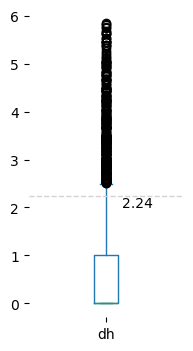

In [18]:
ax = VOCAB.dh.plot.box(figsize=(2,4))
vline = VOCAB.dh.quantile(.9).round(2)
ax.axhline(vline, ls='--', lw=1, c='lightgray')
ax.annotate(vline, xy=(1.1,2))
sns.despine(left=True, bottom=True)
plt.show()

In [19]:
dh_thresh = vline

sig_mask = VOCAB.dh > dh_thresh
SIGS = VOCAB[sig_mask].index
len(VOCAB), len(SIGS)

(4447, 444)

In [20]:
SIGS = VOCAB.sort_values('dh').tail(500).index

# CTM to TFIDF

In [21]:
TF = CTM[SIGS]
DF = TF[TF > 0].sum()
IDF = np.log((n_chunks+1)/(DF+1)+1)
TFIDF = TF * IDF
L2_norm = np.sqrt((TFIDF**2).sum(1))
TFIDF_L2 = TFIDF.div(L2_norm, axis=0)

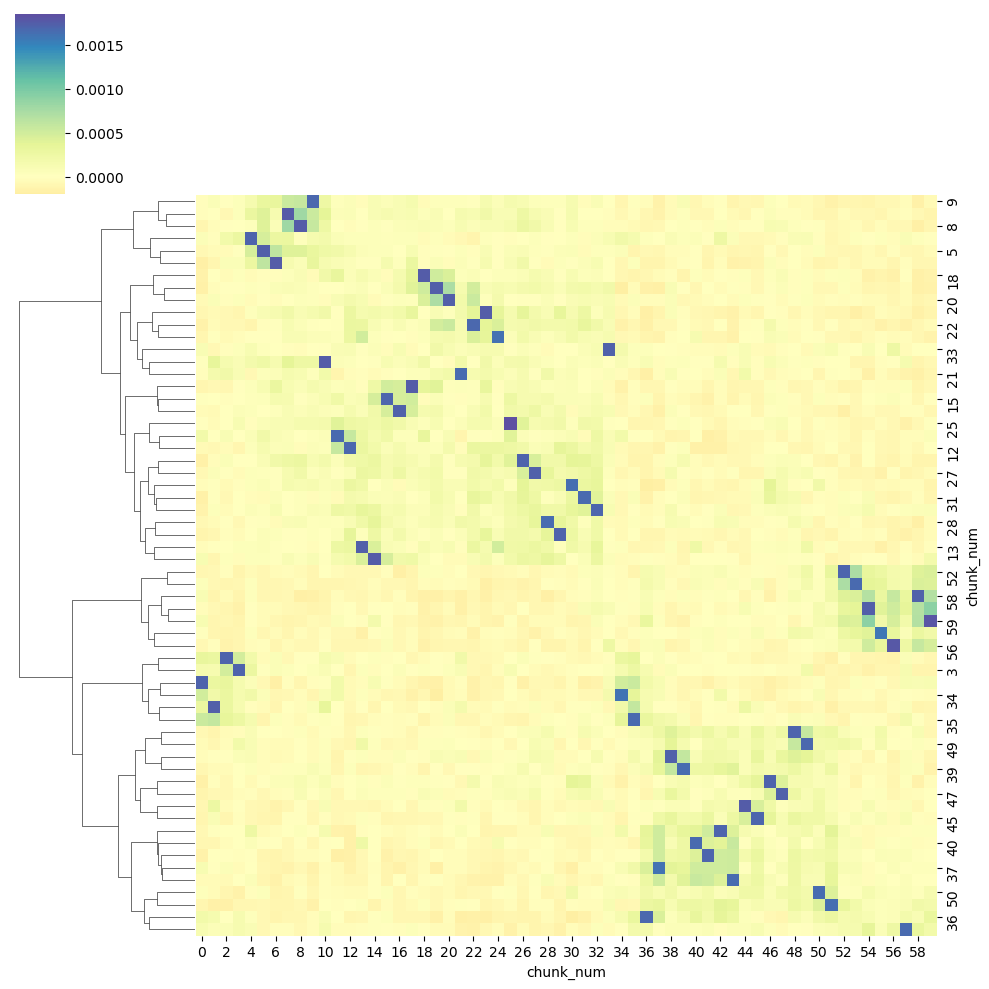

In [22]:
sns.clustermap(TFIDF_L2.T.cov(), cmap="Spectral", center=0, col_cluster=None, 
    metric='euclidean',
    method='ward')
plt.show()

# Save

In [23]:
TOKEN.to_csv(f"{src_id}-TOKEN.csv", index=True)
VOCAB.to_csv(f"{src_id}-VOCAB.csv", index=True)
DOC.to_csv(f"{src_id}-DOC.csv", index=True)
CHUNK.to_csv(f"{src_id}-CHUNK-{n_chunks}.csv", index=True)
TFIDF_L2.to_csv(f"{src_id}-TFIDF-{n_chunks}.csv", index=True)